<a href="https://colab.research.google.com/github/Arnold-XV/cvl_assignment1/blob/main/CVL_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image Enhancement

##Dependencies

In [8]:
from google.colab import files
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

##Low Contrast Image using Contrast stretching or Histogram equalization

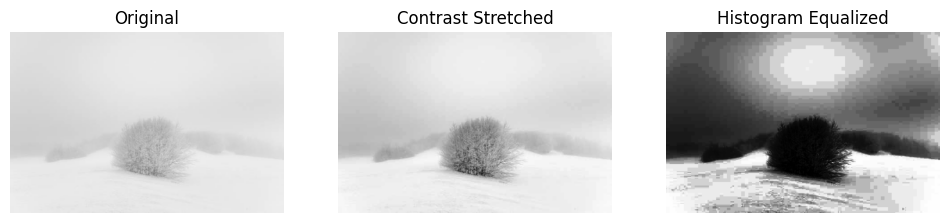

In [9]:
#load image
image = cv.imread('lowcontrast1.jpg') #change the filename

#use contrast stretching
def contrast_stretching(image):
    a = 0
    b = 255
    min_val = np.min(image)
    max_val = np.max(image)
    lcstretched = (image - min_val) * ((b-a) / (max_val - min_val))
    return lcstretched.astype(np.uint8)
lcstretched = contrast_stretching(image)

#use histogram equalization
def histogram_equalization(image):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    total_pixels = gray.shape[0] * gray.shape[1]
    freq = np.bincount(gray.flatten(), minlength=256)
    p_l = freq / total_pixels
    c_p = np.cumsum(p_l)
    map_values = np.floor(c_p * 255).astype(np.uint8)
    lcequalized_gray = map_values[gray]
    return cv.cvtColor(lcequalized_gray, cv.COLOR_GRAY2BGR)
lcequalized = histogram_equalization(image)

# show original and enhanced versions
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(lcstretched, cv.COLOR_BGR2RGB))
plt.title('Contrast Stretched')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(lcequalized, cv.COLOR_BGR2RGB))
plt.title('Histogram Equalized')
plt.axis('off')

plt.show()

##High Contrast Image using Contrast Streching or Histogram Equalization

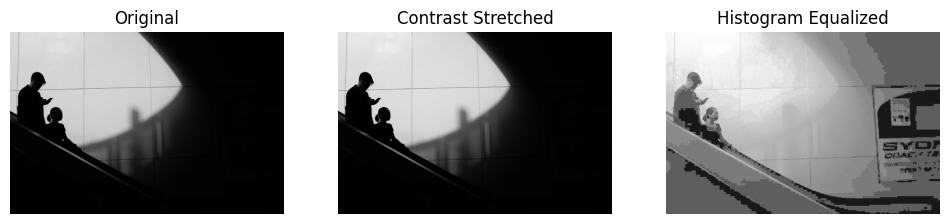

In [10]:
#load image
image = cv.imread('highcontrast.png') #change the filename

#use contrast stretching
def contrast_stretching(image):
    a = 0
    b = 255
    min_val = np.min(image)
    max_val = np.max(image)
    hcstretched = (image - min_val) * ((b-a) / (max_val - min_val))
    return hcstretched.astype(np.uint8)
hcstretched = contrast_stretching(image)

#use histogram equalization
def histogram_equalization(image):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    total_pixels = gray.shape[0] * gray.shape[1]
    freq = np.bincount(gray.flatten(), minlength=256)
    p_l = freq / total_pixels
    c_p = np.cumsum(p_l)
    map_values = np.floor(c_p * 255).astype(np.uint8)
    hcequalized_gray = map_values[gray]
    return cv.cvtColor(hcequalized_gray, cv.COLOR_GRAY2BGR)
hcequalized = histogram_equalization(image)

# show original and enhanced versions
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(hcstretched, cv.COLOR_BGR2RGB))
plt.title('Contrast Stretched')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(hcequalized, cv.COLOR_BGR2RGB))
plt.title('Histogram Equalized')
plt.axis('off')

plt.show()

##Bright Image using Histogram Equalization or Exponential Transformation

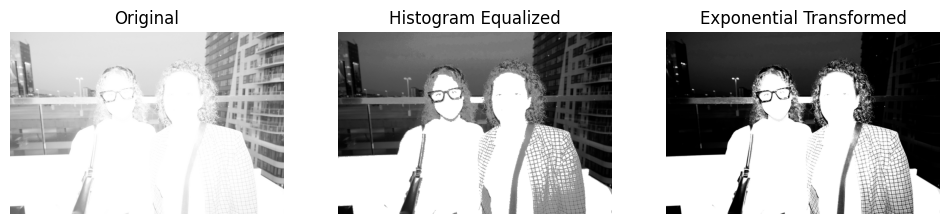

In [11]:
#load image
image = cv.imread('brightimage.png', cv.IMREAD_GRAYSCALE)

#use histogram equalization
def histogram_equalization(image):
    total_pixels = image.shape[0] * image.shape[1]
    freq = np.bincount(image.flatten(), minlength=256)
    p_l = freq / total_pixels
    c_p = np.cumsum(p_l)
    map_values = np.floor(c_p * 255).astype(np.uint8)
    equalized_gray = map_values[image]
    return equalized_gray
biequalized = histogram_equalization(image)

def power_law_transformation(image, gamma):
    r = image.astype(np.float32) / 255.0
    c = 255.0
    s = c * np.power(r, gamma)
    return np.uint8(s)
biexp_transformed = power_law_transformation(image, gamma=15)

#show original and enhanced versions
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(biequalized, cv.COLOR_BGR2RGB))
plt.title('Histogram Equalized')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(biexp_transformed, cv.COLOR_BGR2RGB))
plt.title('Exponential Transformed')
plt.axis('off')

plt.show()

##Dark Image using Histogram equalization or log transformation

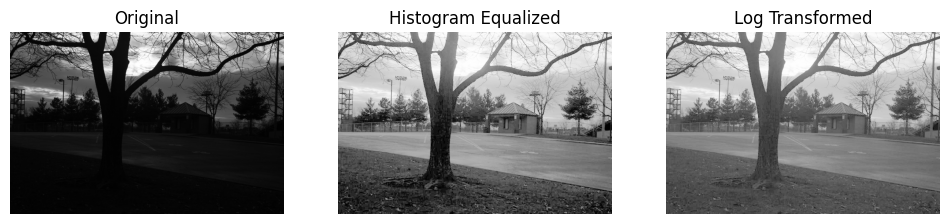

In [12]:
#load image
image = cv.imread('lowlight.jpg', cv.IMREAD_GRAYSCALE)

#use histogram equalization
def histogram_equalization(image):
    total_pixels = image.shape[0] * image.shape[1]
    freq = np.bincount(image.flatten(), minlength=256)
    p_l = freq / total_pixels
    c_p = np.cumsum(p_l)
    map_values = np.floor(c_p * 255).astype(np.uint8)
    equalized_gray = map_values[image]
    return equalized_gray
diequalized = histogram_equalization(image)

#use log transformation
def log_transformation(image):
    max_val = float(np.max(image))
    c = 255 / np.log(1 + max_val)
    log_image = c * np.log(1 + image.astype(np.float32))
    return np.uint8(log_image)
dilog_transformed = log_transformation(image)

#show original and enhanced versions
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(diequalized, cmap='gray')
plt.title('Histogram Equalized')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(dilog_transformed, cmap='gray')
plt.title('Log Transformed')
plt.axis('off')

plt.show()

##Uneven Illumination using Root Transformation

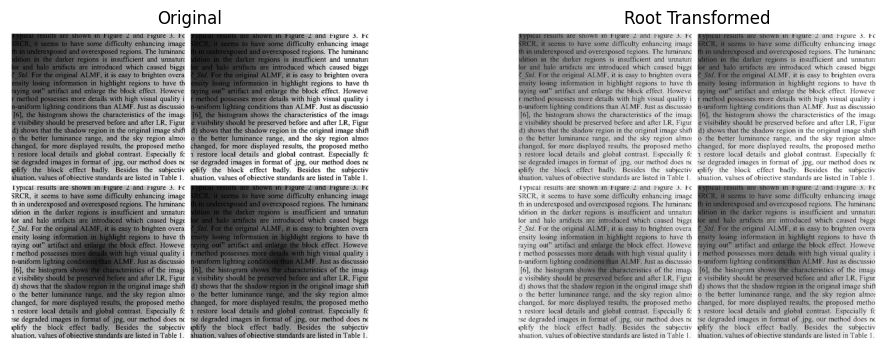

In [13]:
#load image
image = cv.imread('unevenillumination.png', cv.IMREAD_GRAYSCALE)

# using root (square root) transformation
def root_transformation(image):
    max_val = float(np.max(image))
    if max_val == 0:
        return image
    c = 255.0 / np.sqrt(max_val)
    root_image = c * np.sqrt(image.astype(np.float32))
    return np.uint8(root_image)
root_transformed = root_transformation(image)

# show original and enhanced versions
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(root_transformed, cmap='gray')
plt.title('Root Transformed')
plt.axis('off')

plt.show()

##Blurry Image sharpen with Laplacian Filter

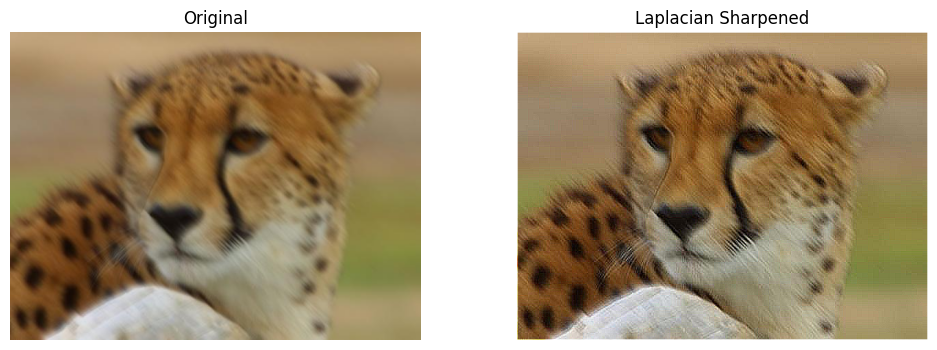

In [14]:
#load image
image = cv.imread('blurryimg.png')

#use laplacian filter
def custom_laplacian_sharpening(image):
    kernel = np.array([[ 1,  1,  1],
                       [ 1, -8,  1],
                       [ 1,  1,  1]], dtype=np.float32)

    kernel_size = 3
    pad_size = kernel_size // 2
    output_laplacian = np.zeros_like(image, dtype=np.float32)

    if len(image.shape) == 3:
        padded_img = np.zeros((image.shape[0] + 2*pad_size, image.shape[1] + 2*pad_size, 3), dtype=np.float32)
        padded_img[pad_size:-pad_size, pad_size:-pad_size, :] = image
        for c in range(3):
            for i in range(image.shape[0]):
                for j in range(image.shape[1]):
                    window = padded_img[i:i+kernel_size, j:j+kernel_size, c]
                    output_laplacian[i, j, c] = np.sum(window * kernel)
    else:
        padded_img = np.zeros((image.shape[0] + 2*pad_size, image.shape[1] + 2*pad_size), dtype=np.float32)
        padded_img[pad_size:-pad_size, pad_size:-pad_size] = image

        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                window = padded_img[i:i+kernel_size, j:j+kernel_size]
                output_laplacian[i, j] = np.sum(window * kernel)
    sharpened = image.astype(np.float32) - output_laplacian
    return np.clip(sharpened, 0, 255).astype(np.uint8)
sharpened = custom_laplacian_sharpening(image)

# show original and sharpened versions
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(sharpened, cv.COLOR_BGR2RGB))
plt.title('Laplacian Sharpened')
plt.axis('off')

plt.show()

##Noisy Image using Median Filter

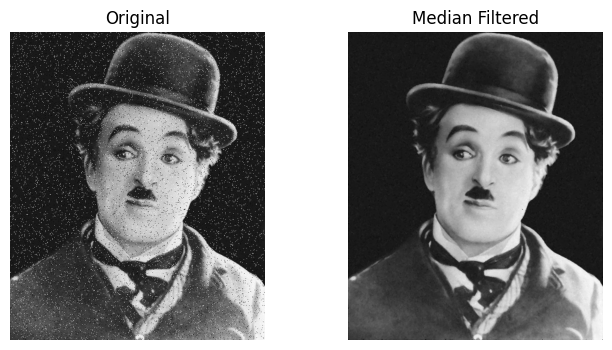

In [15]:
#load image
image = cv.imread('noisyimg.png', cv.IMREAD_GRAYSCALE)
kernel_size = 3

#apply zero padding
def apply_zero_padding(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size), dtype=np.float32)
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image

#manual sorting for median (bubble sort)
def manual_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(n - i - 1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

#use median filter
def median_filter(image, kernel_size):
    pad_size = kernel_size // 2
    padded_img = apply_zero_padding(image, pad_size)
    output_img = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded_img[i:i+kernel_size, j:j+kernel_size]
            # flatten window and find median
            flat = []
            for r in range(kernel_size):
                for c in range(kernel_size):
                    flat.append(float(window[r, c]))
            flat = manual_sort(flat)
            output_img[i, j] = flat[len(flat) // 2]

    return np.clip(output_img, 0, 255).astype(np.uint8)
median_filtered = median_filter(image, kernel_size)

# show original and enhanced versions
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filtered')
plt.axis('off')

plt.show()

##Oversharpened Image using Gaussian Filter

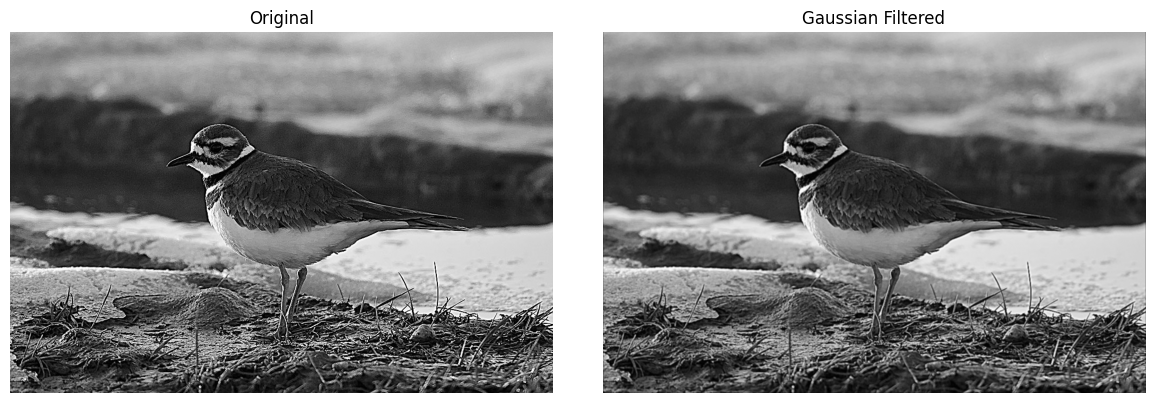

In [16]:
#load image
image = cv.imread('oversharpenedimg.jpg', cv.IMREAD_GRAYSCALE)
kernel_size = 3

def apply_zero_padding(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size), dtype=np.float32)
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image

#use gaussian filter
def generate_gaussian_kernel(size, sigma):
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            kernel[i, j] = (1.0 / (2.0 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2.0 * sigma**2))
    return kernel / np.sum(kernel)
def gaussian_filter(image, kernel_size, sigma=1.0):
    pad_size = kernel_size // 2
    padded_img = apply_zero_padding(image, pad_size)
    output_img = np.zeros_like(image, dtype=np.float32)
    kernel = generate_gaussian_kernel(kernel_size, sigma)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded_img[i:i+kernel_size, j:j+kernel_size]
            output_img[i, j] = np.sum(window * kernel)
    return np.clip(output_img, 0, 255).astype(np.uint8)
gaussian_filtered = gaussian_filter(image, kernel_size)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title('Gaussian Filtered')
plt.axis('off')

plt.tight_layout()
plt.show()